## Spatial M3C2 QC plot — stable-terrain co-registration check

For each processed date, the stable-terrain M3C2 distances (day cloud vs. the
shared reference) **before and after co-registration** are binned onto a 2D
easting/northing grid — the point-cloud analogue of the demcoreg elevation
difference maps.

A good co-registration shows a **random, unstructured pattern near zero** after
coreg: no tilt (spatial gradient), stripes, or zones of systematic offset.

`qc_m3c2(date)` runs the whole check for one date; the loop below applies it to
every processed monthly date. The site (paths) comes from `site_config.py` —
point it at the glacier you want to QC before running.

In [27]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import py4dgeo

import site_config as site
from cntp.io import load_las
from cntp.coreg import extract_stable_terrain, run_m3c2
from tools import plot_m3c2_spatial, plot_m3c2_3d

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
# ── Shared reference (built once by the pipeline, reused for every date) ───────
# REF_DOWNSAMPLE must match the `ref_downsample` used when the dates were processed.
REF_DOWNSAMPLE = 0.40
stable_ref_path = (
    site.out / "_ref_cache" / f"Reference_UAV_TLC_PCS_ds{REF_DOWNSAMPLE:.2f}_stable.las"
)
assert stable_ref_path.exists(), f"missing stable reference: {stable_ref_path}"

ref_stable = load_las(stable_ref_path)        # already stable-filtered — load as-is
epoch_ref  = py4dgeo.Epoch(ref_stable[:, :3])
print(f"ref_stable: {len(ref_stable):,} pts  ({stable_ref_path.name})")

# ── Processed monthly dates to QC ───────────────────────────────
MONTHLY_DATES = [
    "2024-01-18", 
    # "2024-02-18", 
    # "2024-03-17", 
    # "2024-04-19",
    # "2024-05-17", 
    # "2024-06-15", 
    # "2024-07-15", 
    # "2024-08-17",
    # "2024-09-18", 
    # "2024-10-16", 
    # "2024-11-15",
]

ref_stable: 490,580 pts  (Reference_UAV_TLC_PCS_ds0.40_stable.las)


In [29]:
def qc_m3c2(date, *, vmax=3.0, show_3d=False, verbose=True):
    """Stable-terrain M3C2 before/after coreg for one date + spatial QC plot.

    Loads the day's single-day and co-registered clouds, extracts stable terrain
    from each, runs M3C2 against the shared `ref_stable`, prints the residual
    stats, and shows the before/after spatial map (and optionally a 3D view).
    Colour scale is fixed to ±`vmax` m (default ±3). Returns a stats dict, or
    None if the date's clouds are missing.
    """
    day_dir    = site.out / date
    tba_before = day_dir / "single_day" / f"{date}_cloud.las"
    tba_after  = day_dir / "coreg" / f"{date}_cloud_coreg_hsfm.las"

    if not (tba_before.exists() and tba_after.exists()):
        print(f"  {date}: SKIP — missing cloud(s)")
        return None

    _, before_stable = extract_stable_terrain(load_las(tba_before))
    _, after_stable  = extract_stable_terrain(load_las(tba_after))

    med_b, nmad_b, std_b, dist_b = run_m3c2(epoch_ref, py4dgeo.Epoch(before_stable[:, :3]))
    med_a, nmad_a, std_a, dist_a = run_m3c2(epoch_ref, py4dgeo.Epoch(after_stable[:, :3]))

    if verbose:
        print(f"{date} — Before  median {med_b:+.3f}  nmad {nmad_b:.3f}  std {std_b:.3f}")
        print(f"{date} — After   median {med_a:+.3f}  nmad {nmad_a:.3f}  std {std_a:.3f}")

    plot_m3c2_spatial(ref_stable, dist_b, dist_a, title=date, vmax=vmax)
    if show_3d:
        plot_m3c2_3d(ref_stable, dist_b, dist_a, title=date, vmax=vmax)

    return dict(
        date=date,
        med_before=med_b, nmad_before=nmad_b, std_before=std_b,
        med_after=med_a, nmad_after=nmad_a, std_after=std_a,
    )

[2026-06-19 14:14:40][INFO] Building KDTree structure with leaf parameter 10
[2026-06-19 14:14:40][INFO] Building KDTree structure with leaf parameter 10
[2026-06-19 14:14:44][INFO] Building KDTree structure with leaf parameter 10
2024-01-18 — Before  median -0.251  nmad 0.699  std 1.369
2024-01-18 — After   median -0.107  nmad 0.417  std 1.220


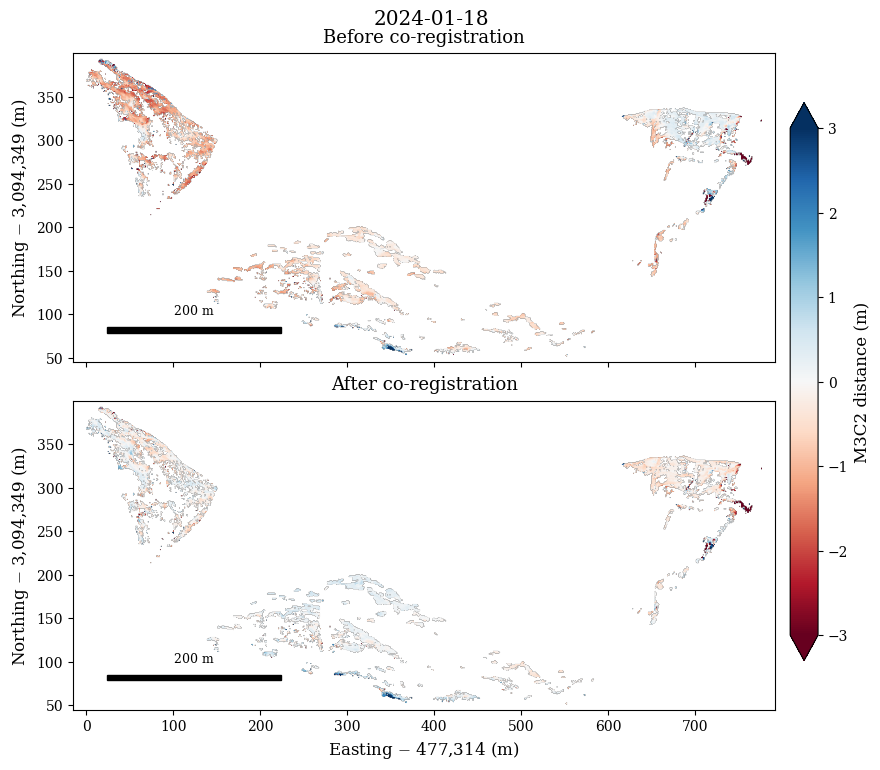

In [30]:
# ── Run the QC plot for every processed monthly date ─────────────────────
results = [qc_m3c2(d, show_3d=False) for d in MONTHLY_DATES]

In [6]:
# ── Summary table — stable-terrain residuals before vs. after coreg ──────────
summary = pd.DataFrame([r for r in results if r]).set_index("date").round(3)
summary

,med_before,nmad_before,std_before,med_after,nmad_after,std_after
date,,,,,,
2024-01-18,0.852,0.558,0.736,-0.0,0.271,0.622
